In [2]:
import os
from pycocotools.coco import COCO
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [7]:
# 파일 경로 설정
#data_root = r"C:\Dev\WheelScan\data"
data_root = r"/Users/dongbae/Dev/WheelScan/data"
train_img_dir = os.path.join(data_root, "train", "images")
train_label_dir = os.path.join(data_root, "train", "labels")

In [8]:
def create_dataframe(label_dir, train_img_dir):
    # 카테고리 매핑
    category_map = {
        0: 'crack',
        1: 'discoloration',
        2: 'flat',
        3: 'shelling',
        4: 'spalling',
        5: 'wheel'
    }

    annotations = []
    label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]
    image_sizes = {}
    
    for label_file in label_files:
        image_name = os.path.splitext(label_file)[0] + '.jpg'
        image_id = os.path.splitext(label_file)[0]
        image_path = os.path.join(train_img_dir, image_name)
        try:
            with Image.open(image_path) as img:
                img_width, img_height = img.size
                image_sizes[image_name] = {'width': img_width, 'height': img_height}
        except Exception as e:
            print(f"Error reading {image_path}: {e}")
            image_sizes[image_name] = {'width': None, 'height': None}
        
        with open(os.path.join(label_dir, label_file), 'r') as f:
            lines = f.readlines()
        
        for line in lines:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            
            class_id = int(parts[0])
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])

            class_name = category_map.get(class_id, f"class_{class_id}")
            
            annotations.append({
                'image_id': image_id,
                'file_name': image_name,
                'category_id': class_id,
                'category_name': class_name,
                'x_center': x_center,
                'y_center': y_center,
                'width': width,
                'height': height,
                'image_width': image_sizes[image_name]['width'],
                'image_height': image_sizes[image_name]['height']
            })
    
    df = pd.DataFrame(annotations)
    return df

In [11]:
df = create_dataframe(train_label_dir, train_img_dir)
print(df.head())

                                        image_id  \
0  D0010_JPG.rf.ec4c98c6a923f4391665c35304e1f54a   
1  L0670_jpg.rf.266b05cbe3ef91717a568aeac2460a78   
2  L0670_jpg.rf.266b05cbe3ef91717a568aeac2460a78   
3  R0689_jpg.rf.d7d864ffd05a5b586c44c234042db14f   
4  R0716_jpg.rf.0889bd7779c7909be15bd1eaf6f701e3   

                                           file_name  category_id  \
0  D0010_JPG.rf.ec4c98c6a923f4391665c35304e1f54a.jpg            4   
1  L0670_jpg.rf.266b05cbe3ef91717a568aeac2460a78.jpg            5   
2  L0670_jpg.rf.266b05cbe3ef91717a568aeac2460a78.jpg            3   
3  R0689_jpg.rf.d7d864ffd05a5b586c44c234042db14f.jpg            5   
4  R0716_jpg.rf.0889bd7779c7909be15bd1eaf6f701e3.jpg            5   

  category_name  x_center  y_center     width    height  image_width  \
0      spalling  0.469782  0.514455  0.220145  0.295693          275   
1         wheel  0.449405  0.381448  0.166648  0.477407         4284   
2      shelling  0.393228  0.464737  0.035002  0.050863 

In [12]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   image_id       499 non-null    object 
 1   file_name      499 non-null    object 
 2   category_id    499 non-null    int64  
 3   category_name  499 non-null    object 
 4   x_center       499 non-null    float64
 5   y_center       499 non-null    float64
 6   width          499 non-null    float64
 7   height         499 non-null    float64
 8   image_width    499 non-null    int64  
 9   image_height   499 non-null    int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 39.1+ KB
None


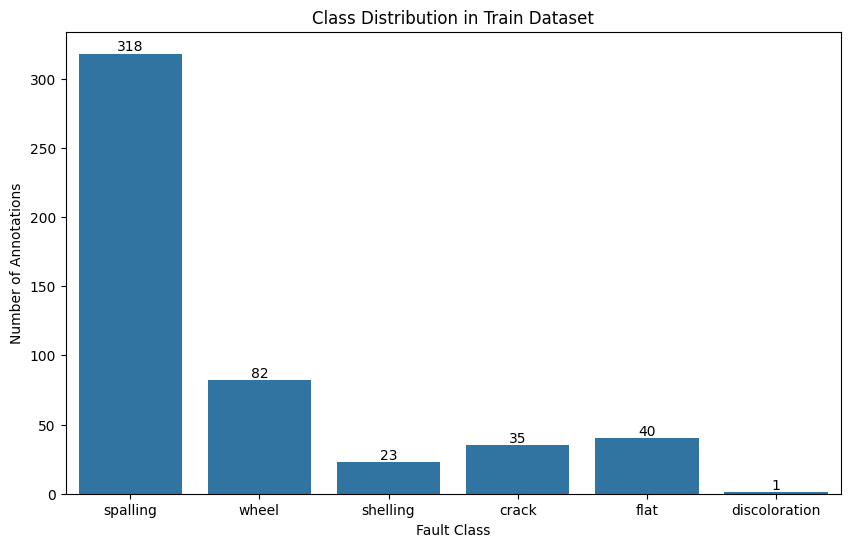

In [ ]:
# 클래스 분포 시각화
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='category_name')
plt.title('Class Distribution in Train Dataset')
plt.xlabel('Fault Class')
plt.ylabel('Number of Annotations')
#plt.xticks(rotation=45)

# 각 막대 위에 갯수 표시
for i in ax.patches:
    ax.text(i.get_x() + i.get_width() / 2, i.get_height(),
            int(i.get_height()),
            ha='center', va='bottom')

plt.show()

class_counts = (
    df['category_id']
    .value_counts()
    .rename_axis('category_id')
    .reset_index(name='count')
)

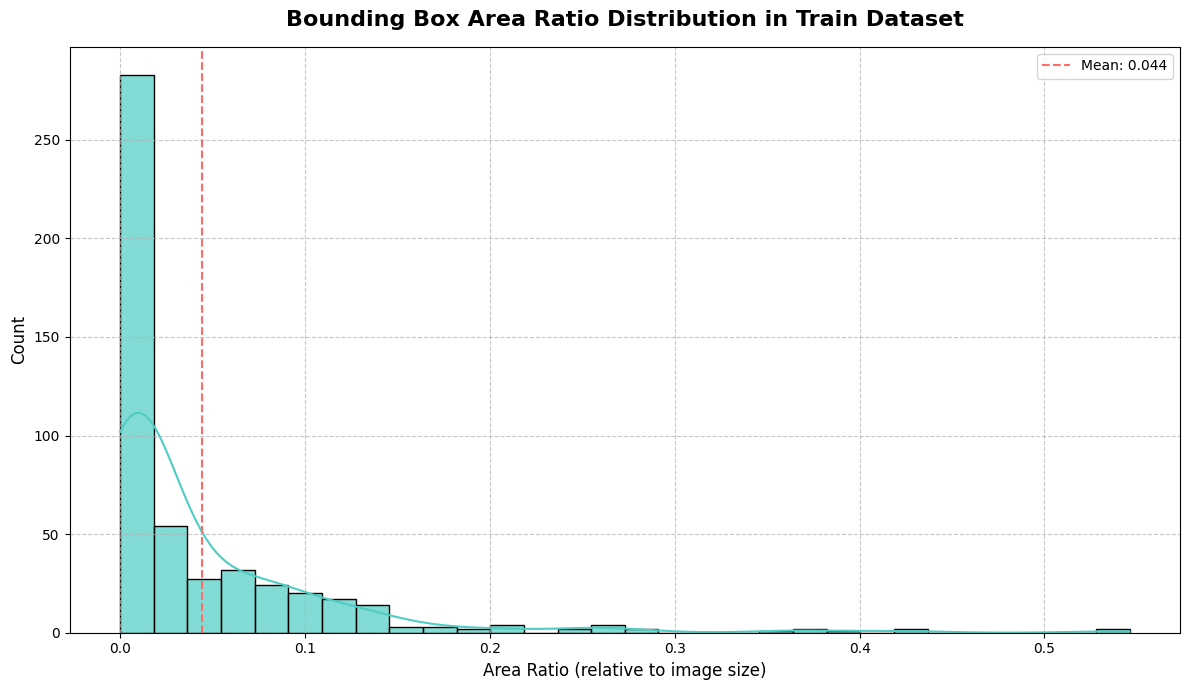

In [17]:
# 바운딩 박스가 이미지 내 차지하는 비율
df['bbox_width_abs'] = df['width'] * df['image_width']
df['bbox_height_abs'] = df['height'] * df['image_height']
# 바운딩 박스 면적 계산
df['area'] = df['bbox_width_abs'] * df['bbox_height_abs']
# 이미지 전체 면적 대비 비율 계산
df['area_ratio'] = df['area'] / (df['image_width'] * df['image_height'])

# 바운딩 박스 면적 비율 분포 시각화
plt.figure(figsize=(12, 7))
sns.histplot(data=df, x='area_ratio', bins=30, kde=True, color='#4ECDC4', alpha=0.7)
plt.title('Bounding Box Area Ratio Distribution in Train Dataset', fontsize=16, pad=15, fontweight='bold')
plt.xlabel('Area Ratio (relative to image size)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(df['area_ratio'].mean(), color='#FF6B6B', linestyle='--', label=f'Mean: {df["area_ratio"].mean():.3f}')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
# filepath: /Users/dongbae/Dev/WheelScan/scripts/check_labels.py
import glob

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
max_class = 5  # 클래스 인덱스 최대값 (클래스가 4개면 3)
print(f"총 라벨 파일 수: {len(label_files)}")

for file in label_files:
    with open(file) as f:
        for i, line in enumerate(f):
            if line.strip() == '':
                continue
            cls = int(line.split()[0])
            if cls < 0 or cls > max_class:
                print(f"잘못된 클래스 인덱스: {file} line {i+1} -> {cls}")

총 라벨 파일 수: 265


In [20]:
import glob

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
empty_files = []
for file in label_files:
    with open(file) as f:
        lines = [line for line in f if line.strip()]
        if len(lines) == 0:
            empty_files.append(file)
print(f"비어있는 라벨 파일 수: {len(empty_files)}")
for f in empty_files:
    print(f)

비어있는 라벨 파일 수: 0


In [21]:
import glob

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
found = False
for file in label_files:
    with open(file) as f:
        for i, line in enumerate(f):
            if line.strip() == '':
                continue
            cls = int(line.split()[0])
            if cls == 4:
                print(f"4번 그룹 라벨 발견: {file} line {i+1} -> {line.strip()}")
                found = True
if not found:
    print("4번 그룹 라벨이 없습니다.")

4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/D0010_JPG.rf.ec4c98c6a923f4391665c35304e1f54a.txt line 1 -> 4 0.4697818181818182 0.5144554455445545 0.22014545454545456 0.2956930693069306
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/R0716_jpg.rf.0889bd7779c7909be15bd1eaf6f701e3.txt line 2 -> 4 0.5311624649859944 0.5405427170868348 0.008520074696545284 0.006635154061624586
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/D0104_jpg.rf.65169b47cf91f36118908ffa0a2bdbd2.txt line 1 -> 4 0.47707812499999996 0.43125 0.05625 0.05416666666666667
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/D0104_jpg.rf.65169b47cf91f36118908ffa0a2bdbd2.txt line 2 -> 4 0.5333281249999999 0.3625 0.05 0.0472291666666667
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/D0123_jpg.rf.2739ff529b3eb17ffe15e02679709338.txt line 1 -> 4 0.54875 0.4233506944444445 0.20056640624999994 0.31250000000000006
4번 그룹 라벨 발견: /Users/dongbae/Dev/WheelScan/data/train/labels/

In [6]:
import glob
from collections import Counter

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
class_counter = Counter()

for file in label_files:
    with open(file) as f:
        for line in f:
            if line.strip() == '':
                continue
            cls = int(line.split()[0])
            class_counter[cls] += 1

for cls in range(6):
    print(f"{cls}번 그룹 라벨 개수: {class_counter[cls]}")

0번 그룹 라벨 개수: 636
1번 그룹 라벨 개수: 295
2번 그룹 라벨 개수: 805
3번 그룹 라벨 개수: 829
4번 그룹 라벨 개수: 0
5번 그룹 라벨 개수: 0


In [22]:
import glob

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
for file in label_files:
    with open(file) as f:
        for i, line in enumerate(f):
            if line.strip() == '':
                continue
            cls = int(line.split()[0])
            if cls < 0:
                print(f"음수 클래스 인덱스 발견: {file} line {i+1} -> {cls}")

In [8]:
import glob
import math

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/*/labels/*.txt')
for file in label_files:
    with open(file) as f:
        for i, line in enumerate(f):
            parts = line.strip().split()
            if len(parts) < 5:
                print(f"좌표값 부족: {file} line {i+1} -> {line.strip()}")
                continue
            try:
                vals = [float(x) for x in parts]
                if any(math.isnan(x) or math.isinf(x) for x in vals):
                    print(f"NaN/inf 포함: {file} line {i+1} -> {line.strip()}")
            except Exception as e:
                print(f"숫자 변환 오류: {file} line {i+1} -> {line.strip()} ({e})")

In [23]:
import os
from glob import glob

img_dir = '/Users/dongbae/Dev/WheelScan/data/valid/images'
label_dir = '/Users/dongbae/Dev/WheelScan/data/valid/labels'

img_files = glob(os.path.join(img_dir, '*'))
img_basenames = [os.path.splitext(os.path.basename(f))[0] for f in img_files]

missing_labels = []
for name in img_basenames:
    label_path = os.path.join(label_dir, name + '.txt')
    if not os.path.exists(label_path):
        missing_labels.append(name)

print(f"라벨 없는 validation 이미지 수: {len(missing_labels)}")
for name in missing_labels:
    print(name)

라벨 없는 validation 이미지 수: 0


In [26]:
import glob
from collections import Counter

label_files = glob.glob('/Users/dongbae/Dev/WheelScan/data/train/labels/*.txt')
class_counter = Counter()

for file in label_files:
    with open(file) as f:
        for line in f:
            if line.strip():
                cls = int(line.split()[0])
                class_counter[cls] += 1

for cls in range(6):  # 클래스 인덱스 0~3
    print(f"{cls}번 클래스 라벨 개수: {class_counter[cls]}")

0번 클래스 라벨 개수: 35
1번 클래스 라벨 개수: 1
2번 클래스 라벨 개수: 40
3번 클래스 라벨 개수: 23
4번 클래스 라벨 개수: 318
5번 클래스 라벨 개수: 82


In [15]:
import glob
from collections import Counter

label_dir = '/Users/dongbae/Dev/WheelScan/data/train/labels'
label_files = glob.glob(f'{label_dir}/*.txt')

# 파일별 1번 클래스 개수 저장
file_class_count = []

for file in label_files:
    with open(file) as f:
        class_counter = Counter(int(line.split()[0]) for line in f if line.strip())
        file_class_count.append((file, class_counter[1]))  # 1번 클래스 개수 저장

# 1번 클래스 개수로 정렬 후 상위 10개 출력
file_class_count.sort(key=lambda x: x[1], reverse=True)
top_10_files = file_class_count[:10]

print("1번 클래스 라벨이 많은 파일 상위 10개:")
for file, count in top_10_files:
    print(f"{file}: {count}개")

1번 클래스 라벨이 많은 파일 상위 10개:
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1505_jpg.rf.71c2ea9d528ac0bb70abbb630e9b79c1.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1503_jpg.rf.24a789ab8209a098fece3b7534084397.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1505_jpg.rf.64b969e8cc57dd6c1fee2cf96fe109e7.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1505_jpg.rf.2be66ec92a6439beb750c437b848e4a3.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1501_jpg.rf.0a74c103b49ff55598ff38febd944c7c.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1505_jpg.rf.a4aae779a90ce45cb8654053cb55f97c.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1501_jpg.rf.c6a03c211eff7b1a8cb410870cd36679.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1501_jpg.rf.389ff85f483a9acd030a2f1672645d11.txt: 3개
/Users/dongbae/Dev/WheelScan/data/train/labels/frame1503_jpg.rf.576ba64723392ce05449770981bb5384.txt: 3개
/Users/dongbae/Dev/WheelScan/d

In [ ]:
import os
from glob import glob

img_dir = '/Users/dongbae/Dev/WheelScan/data/valid/images'
label_dir = '/Users/dongbae/Dev/WheelScan/data/valid/labels'

img_files = glob(os.path.join(img_dir, '*'))
img_basenames = [os.path.splitext(os.path.basename(f))[0] for f in img_files]

missing_labels = []
for name in img_basenames:
    label_path = os.path.join(label_dir, name + '.txt')
    if not os.path.exists(label_path):
        missing_labels.append(name)

print(f"라벨 없는 validation 이미지 수: {len(missing_labels)}")
for name in missing_labels:
    print(name)

라벨 없는 validation 이미지 수: 0
